# GARQ Metacell Learning Tutorial

In [1]:

import os
import torch
import random
import argparse
import matplotlib
import numpy as np
import scanpy as sc
import seaborn as sns
from model import GARQ
from matplotlib import rcParams
from alive_progress import alive_bar
from engine import train_one_epoch, warm_one_epoch, inference, init_gart_anchors
from data_utils import load_data, compute_metacell
from eval_utils import (
    plot_metacell_umap,
    plot_metacell_size,
    plot_celltype_purity,
    plot_compactness_separation,
)

/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. I

In [3]:
args = argparse.Namespace(
    data_file=["/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_rna.h5ad","/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_atac.h5ad","/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_adt.h5ad"],
    data_type=["RNA","ATAC","ADT"],
    save_name="GSE158013",
    type_key="celltype",
    n_GARQs=637,
    k_knn=5,
    epoch=300,
    batch_size=512,
    converge_threshold=10,
    seed=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.random.manual_seed(args.seed)
if args.device == "cuda":
    torch.cuda.manual_seed_all(args.seed)

device = torch.device(args.device)

In [4]:
adata_list, dataloader_train, dataloader_eval, input_dims = load_data(args)
omics_num = len(adata_list)

net = GARQ(
    input_dims=input_dims,
    data_types=args.data_type,
    entry_num=args.n_GARQs,
    k_knn=args.k_knn,
).to(device)

optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-2)

print("n_GARQs:", args.n_GARQs)

init_gart_anchors(
    model=net,
    data_types=args.data_type,
    dataloader=dataloader_train,
    device=device,
)
if omics_num == 1:
    net.copy_decoder_q()

warm_epochs = min(50, int(args.epoch * 0.2))
print("warm_epochs:", warm_epochs)

with alive_bar(args.epoch, enrich_print=False) as bar:
    loss_rec_his = loss_vq_his = 1e7
    stable_epochs = 0

    for epoch in range(args.epoch):
        bar()
        if epoch < warm_epochs:
            warm_one_epoch(
                model=net,
                data_types=args.data_type,
                dataloader=dataloader_train,
                optimizer=optimizer,
                epoch=epoch,
                device=device,
            )
        else:
            loss_rec, loss_vq = train_one_epoch(
                model=net,
                data_types=args.data_type,
                dataloader=dataloader_train,
                optimizer=optimizer,
                epoch=epoch,
                device=device,
            )
            converge = (abs(loss_vq_his - loss_vq) <= 1e-5) and (
                abs(loss_rec_his - loss_rec) <= 1e-5
            )
            if converge:
                stable_epochs += 1
                if stable_epochs >= args.converge_threshold:
                    print("Early Stopping.")
                    break
            else:
                stable_epochs = 0
                loss_rec_his = loss_rec
                loss_vq_his = loss_vq



=======Loading and Preprocessing Data=======
Data of 3 omics in total


/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_rna.h5ad loaded with shape [25517, 3173]


/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_atac.h5ad loaded with shape [25517, 30000]
/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_adt.h5ad loaded with shape [25517, 46]
n_GARQs: 637


WARNING clustering 1024 points to 637 centroids: please provide at least 24843 training points


GARQ Initialization completed.
warm_epochs: 50
Epoch 1, RNA: recon_loss=0.2303 , ATAC: recon_loss=0.2516 , ADT: recon_loss=6.8220
Epoch 20, RNA: recon_loss=0.2001 , ATAC: recon_loss=0.1058 , ADT: recon_loss=2.0107
Epoch 40, RNA: recon_loss=0.1934 , ATAC: recon_loss=0.1030 , ADT: recon_loss=1.8787
Epoch 60, RNA: recon_loss=0.1884 recon_loss Q=0.2149 , ATAC: recon_loss=0.1010 recon_loss Q=0.1085 , ADT: recon_loss=1.8380 recon_loss Q=2.5700 , Anchers: loss=0.0123
Epoch 80, RNA: recon_loss=0.1844 recon_loss Q=0.2132 , ATAC: recon_loss=0.0993 recon_loss Q=0.1058 , ADT: recon_loss=1.8195 recon_loss Q=2.5378 , Anchers: loss=0.0112
Epoch 100, RNA: recon_loss=0.1812 recon_loss Q=0.2113 , ATAC: recon_loss=0.0976 recon_loss Q=0.1050 , ADT: recon_loss=1.8057 recon_loss Q=2.5202 , Anchers: loss=0.0119
Epoch 120, RNA: recon_loss=0.1786 recon_loss Q=0.2099 , ATAC: recon_loss=0.0965 recon_loss Q=0.1046 , ADT: recon_loss=1.7965 recon_loss Q=2.5105 , Anchers: loss=0.0114
Epoch 140, RNA: recon_loss=0.176

In [5]:
embeds, ids, delta_confs, rec_q_percent, loss_ancher = inference(
    model=net, data_types=args.data_type, data_loader=dataloader_eval, device=device
)

print("* Quantized Recon Percent:", rec_q_percent)
print("* Anchers Loss:", loss_ancher)

os.makedirs("./save/", exist_ok=True)

for i in range(omics_num):
    metacell_path = (
        "./save/" + args.save_name + "_" + args.data_type[i] + "_"
        + str(args.n_GARQs) + "metacell_k" + str(args.k_knn) + ".h5ad"
    )
    metacell_adata = compute_metacell(adata_list[i], ids, args)
    metacell_adata.write_h5ad(metacell_path)
    print(args.data_type[i] + " metacell data saved at:", metacell_path)

assignment_path = (
    "./save/" + args.save_name + "_" + str(args.n_GARQs) + "metacell_k" + str(args.k_knn) + "_ids.h5ad"
)
adata = sc.AnnData(embeds, dtype=np.float32)
adata.obs["metacell"] = ids
if args.type_key in adata_list[0].obs_keys():
    adata.obs[args.type_key] = adata_list[0].obs[args.type_key].values

import IPython.display
if not hasattr(IPython.display, "set_matplotlib_formats"):
    IPython.display.set_matplotlib_formats = lambda *args, **kwargs: None
    
sc.set_figure_params(figsize=(7, 7), dpi=300)
sc.pp.neighbors(adata, use_rep="X", metric="cosine")
sc.tl.umap(adata)
if args.type_key in adata.obs_keys():
    sc.pl.umap(
        adata,
        color=[args.type_key],
        save="_" + args.save_name + "_embedding_k" + str(args.k_knn) + ".png",
        palette=sns.color_palette("husl", np.unique(adata.obs[args.type_key].values).size),
        show=False,
    )
rcParams.update(matplotlib.rcParamsDefault)
adata.write_h5ad(assignment_path)
print("Metacell assignment saved at:", assignment_path)

fig_save_name = args.save_name + "_" + str(args.n_GARQs) + "metacell_k" + str(args.k_knn)
plot_metacell_umap(adata, fig_save_name)
plot_metacell_size(adata, fig_save_name)
if args.type_key in adata.obs_keys():
    plot_celltype_purity(adata, adata.obs[args.type_key], fig_save_name)
for i in range(omics_num):
    plot_compactness_separation(
        dataloader_train.dataset.raw_list[i].numpy(),
        adata,
        fig_save_name + "_" + args.data_type[i],
        omics_num > 1,
    )



* Quantized Recon Percent: 0.9005743265151978
* Anchers Loss: 0.4679520229977401


/home/zhangpeiru/vscode/GARQ/data_utils.py:131: RuntimeWarning: Mean of empty slice.
  [data[meta_ids == i].mean(axis=0) for i in range(meta_ids.max() + 1)]
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: divide by zero encountered in divide
  ret = um.true_divide(
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/zhangpeiru/vscode/GARQ/data_utils.py:140: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  type_int = torch.from_numpy(adata.obs[a

RNA metacell data saved at: ./save/GSE158013_RNA_637metacell_k5.h5ad


/home/zhangpeiru/vscode/GARQ/data_utils.py:131: RuntimeWarning: Mean of empty slice.
  [data[meta_ids == i].mean(axis=0) for i in range(meta_ids.max() + 1)]
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: divide by zero encountered in divide
  ret = um.true_divide(
/home/zhangpeiru/.conda/envs/MetqQ2/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ATAC metacell data saved at: ./save/GSE158013_ATAC_637metacell_k5.h5ad
ADT metacell data saved at: ./save/GSE158013_ADT_637metacell_k5.h5ad


...

/home/zhangpeiru/vscode/GARQ/eval_utils.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(


Correlation Loaded from: ./save/GSE158013_ATAC_25517cells_correlation.npy
* Average Compactness Score: 0.14988038573242837
* Average Separation Score: 0.7827928018882019


/home/zhangpeiru/vscode/GARQ/eval_utils.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(


Correlation Loaded from: ./save/GSE158013_ADT_25517cells_correlation.npy
* Average Compactness Score: 0.7792440226736097
* Average Separation Score: 0.08053294419261241


/home/zhangpeiru/vscode/GARQ/eval_utils.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(


Loading data...
Metacell shapes: RNA (608, 17882), ATAC (608, 128853), ADT (608, 46)
Single-cell shapes: RNA (25517, 17882), ATAC (25517, 128853), ADT (25517, 46)

Preprocessing...


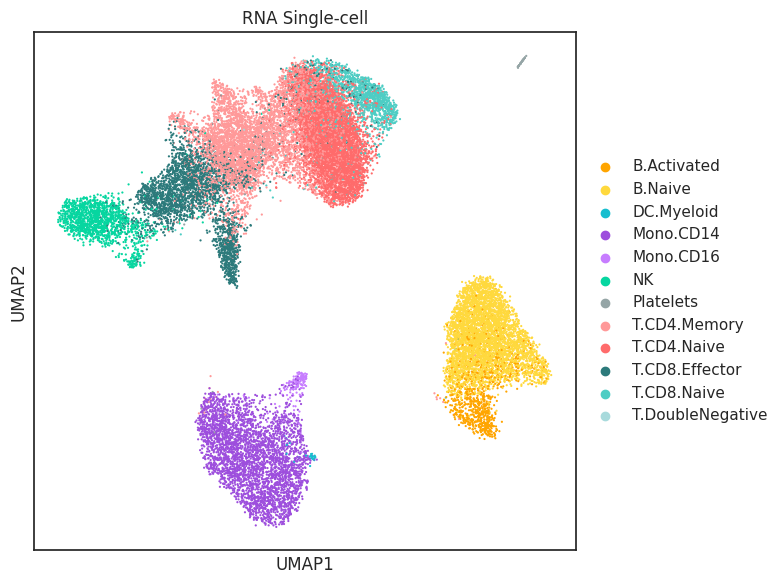

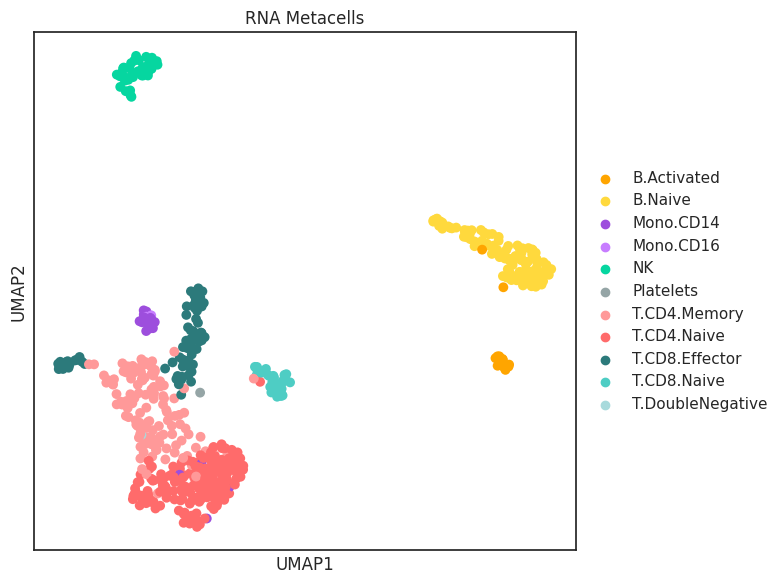

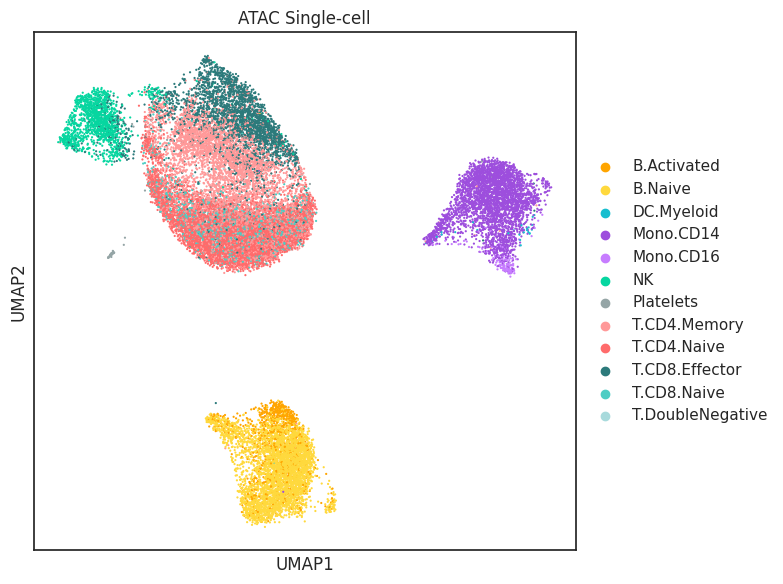

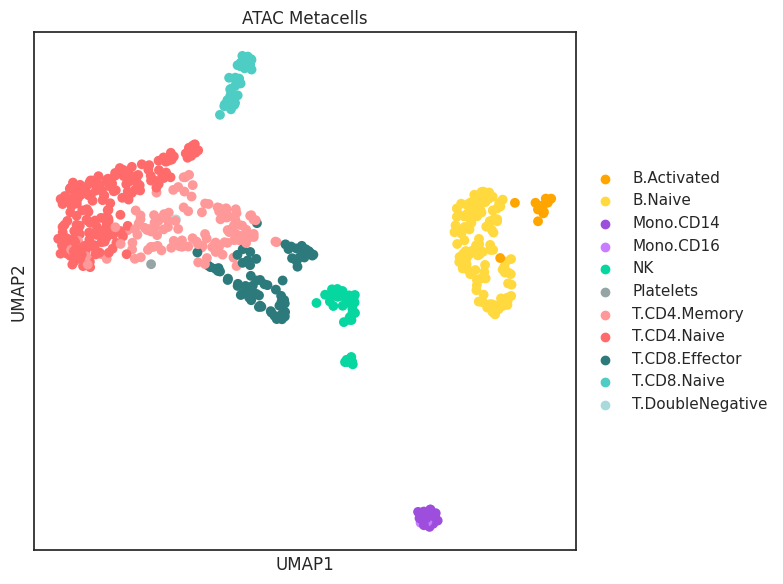

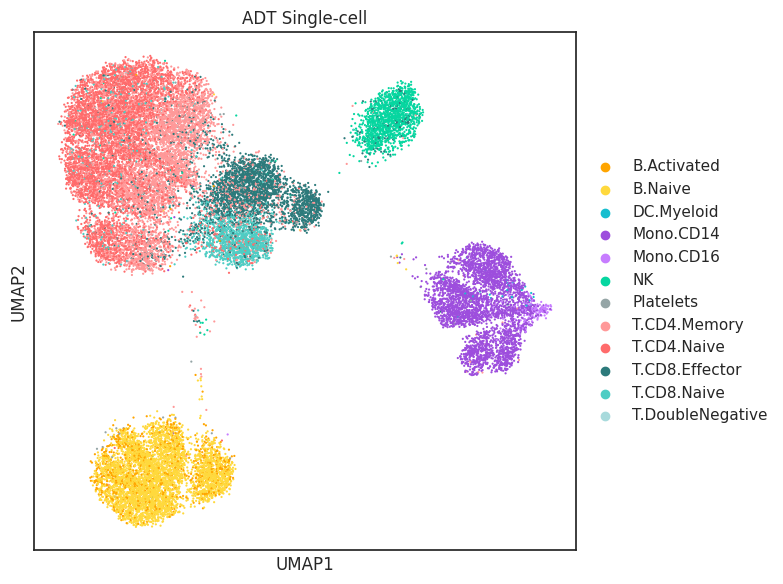

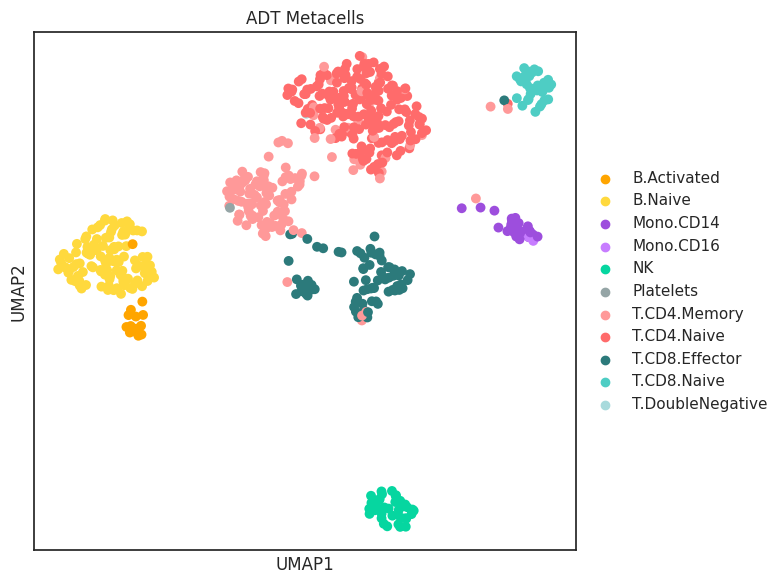

In [6]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

CELLTYPE_COLOR_MAP = {
    "T.CD4.Naive": "#FF6B6B",
    "T.CD4.Memory": "#FF9999",
    "T.CD8.Naive": "#4ECDC4",
    "T.CD8.Effector": "#2C7A7B",
    "T.DoubleNegative": "#A8DADC",
    "B.Naive": "#FFD93D",
    "B.Activated": "#FFA500",
    "Mono.CD14": "#9D4EDD",
    "Mono.CD16": "#C77DFF",
    "NK": "#06D6A0",
    "DC.Myeloid": "#17becf",
    "Platelets": "#95A5A6",
}

print("Loading data...")

rna_ad = sc.read('/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_rna.h5ad')
rna    = sc.read('/home/zhangpeiru/vscode/MetaQ-main/ours/A_xiaorong/A_ag_gart/bash/save/GSE158013637_RNA_637metacell_k5.h5ad')
atac_ad = sc.read('/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_atac.h5ad')
atac    = sc.read('/home/zhangpeiru/vscode/MetaQ-main/ours/A_xiaorong/A_ag_gart/bash/save/GSE158013637_ATAC_637metacell_k5.h5ad')
adt_ad  = sc.read('/home/zhangpeiru/data/RNA_ATAC_ADT/GSE158013/GSE158013_adt.h5ad')
adt     = sc.read('/home/zhangpeiru/vscode/MetaQ-main/ours/A_xiaorong/A_ag_gart/bash/save/GSE158013637_ADT_637metacell_k5.h5ad')
meta    = sc.read('/home/zhangpeiru/vscode/MetaQ-main/ours/A_xiaorong/A_ag_gart/bash/save/GSE158013637_637metacell_k5_ids.h5ad')

print(f"Metacell shapes: RNA {rna.shape}, ATAC {atac.shape}, ADT {adt.shape}")
print(f"Single-cell shapes: RNA {rna_ad.shape}, ATAC {atac_ad.shape}, ADT {adt_ad.shape}")

def preprocess_modality(adata, modality='rna', n_top_genes=2000, n_pcs=50):
    adata_proc = adata.copy()
    if modality == 'rna':
        sc.pp.normalize_total(adata_proc, target_sum=1e4)
        sc.pp.log1p(adata_proc)
        sc.pp.highly_variable_genes(adata_proc, n_top_genes=n_top_genes)
        adata_proc = adata_proc[:, adata_proc.var['highly_variable']]
        sc.pp.scale(adata_proc, max_value=10)
        sc.tl.pca(adata_proc, n_comps=n_pcs)
    elif modality == 'atac':
        if 'X_lsi' not in adata_proc.obsm:
            sc.pp.normalize_total(adata_proc, target_sum=1e4)
            sc.pp.log1p(adata_proc)
            sc.tl.pca(adata_proc, n_comps=n_pcs)
    elif modality == 'adt':
        sc.pp.normalize_total(adata_proc, target_sum=1e4)
        sc.pp.log1p(adata_proc)
        sc.pp.scale(adata_proc)
        sc.tl.pca(adata_proc, n_comps=min(20, adata_proc.shape[1]-1))
    sc.pp.neighbors(adata_proc, use_rep='X_pca')
    sc.tl.umap(adata_proc)
    return adata_proc

print("\nPreprocessing...")
rna_sc   = preprocess_modality(rna_ad,  'rna',  n_top_genes=2000)
rna_mc   = preprocess_modality(rna,     'rna',  n_top_genes=2000)
atac_sc  = preprocess_modality(atac_ad, 'atac')
atac_mc  = preprocess_modality(atac,    'atac')
adt_sc   = preprocess_modality(adt_ad,  'adt')
adt_mc   = preprocess_modality(adt,     'adt')


if 'celltype' not in rna_sc.obs.columns:
    sc.tl.leiden(rna_sc, resolution=0.5, key_added='celltype')

for adata in [rna_mc, atac_sc, atac_mc, adt_sc, adt_mc]:
    if 'celltype' not in adata.obs.columns:
        shared = rna_sc.obs['celltype'].reindex(adata.obs.index)
        adata.obs['celltype'] = shared.values

plot_configs = [
    (rna_sc,  'RNA Single-cell',  10),
    (rna_mc,  'RNA Metacells',   200),
    (atac_sc, 'ATAC Single-cell', 10),
    (atac_mc, 'ATAC Metacells',  200),
    (adt_sc,  'ADT Single-cell',  10),
    (adt_mc,  'ADT Metacells',   200),
]

for adata, title, pt_size in plot_configs:
    fig, ax = plt.subplots(figsize=(8, 6))
    sc.pl.umap(
        adata,
        color='celltype',
        ax=ax,
        show=False,
        title=title,
        legend_loc='right margin',
        s=pt_size,
        palette=CELLTYPE_COLOR_MAP
    )
    plt.tight_layout()
    plt.show()

  Compactness - RNA: 607 个样本
  Compactness - ATAC: 607 个样本
  Compactness - ADT: 607 个样本
  Separation - RNA: 607 个样本
  Separation - ATAC: 607 个样本
  Separation - ADT: 607 个样本


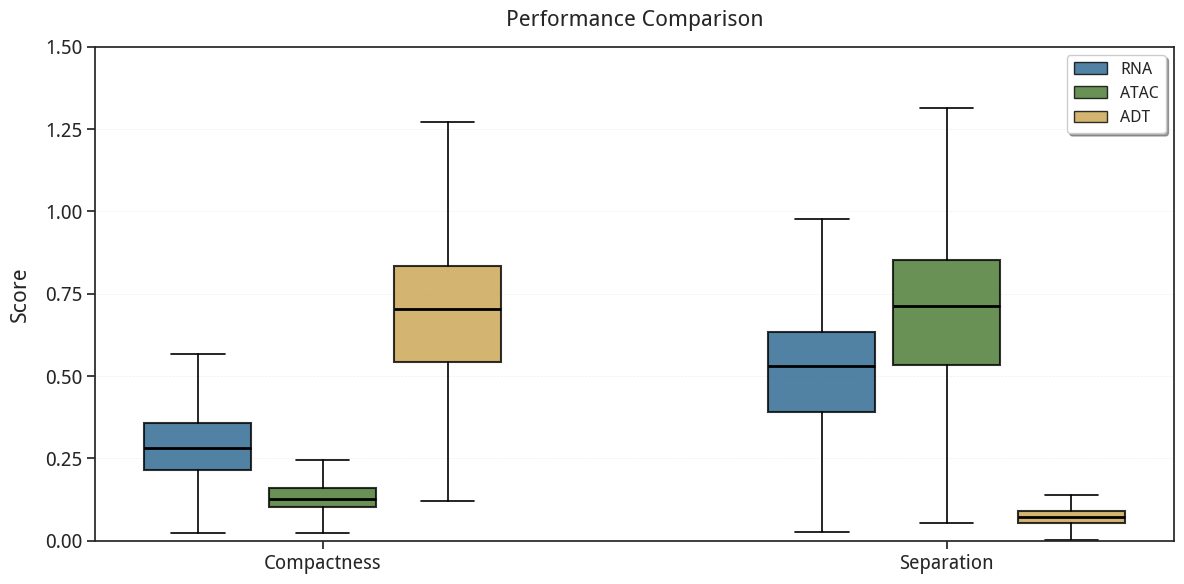

In [9]:
import matplotlib.pyplot as plt
import os
import numpy as np
import warnings
from scipy import stats

warnings.filterwarnings("ignore")

def read_compactness_data(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"文件不存在: {file_path}")
    values = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    values.append(float(line))
                except ValueError:
                    print(f"警告: 非数值内容已跳过: {line}")
    return values

def plot_grouped_modality_boxplot(data_dict, y_label, y_lim, y_tick_interval, title):
    metrics    = list(data_dict.keys())
    modalities = list(data_dict[metrics[0]].keys())

    colors = {'RNA': '#25638e', 'ATAC': '#43762c', 'ADT': '#c9a24c'}

    box_width   = 0.6
    group_width = len(modalities) + 0.5

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, metric in enumerate(metrics):
        group_center = i * group_width + group_width / 2
        data_lists, positions, box_colors = [], [], []

        for j, modality in enumerate(modalities):
            offset = (j - len(modalities) / 2 + 0.5) * (box_width + 0.1)
            pos = group_center + offset
            positions.append(pos)
            data_lists.append(data_dict[metric][modality])
            box_colors.append(colors.get(modality, '#CCCCCC'))

        bp = ax.boxplot(
            data_lists, positions=positions, widths=box_width,
            patch_artist=True, showfliers=False, manage_ticks=False
        )
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)
        for element in ['whiskers', 'caps']:
            plt.setp(bp[element], color='black', linewidth=1.2)
        plt.setp(bp['medians'], color='black', linewidth=2)

    group_centers = [i * group_width + group_width / 2 for i in range(len(metrics))]
    ax.set_xticks(group_centers)
    ax.set_xticklabels(metrics, fontsize=14, style='italic', fontweight='bold')
    ax.set_ylim(y_lim)
    ax.set_yticks(np.arange(y_lim[0], y_lim[1] + 0.01, y_tick_interval))
    ax.set_ylabel(y_label, fontsize=16, labelpad=10)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(title, fontsize=16, pad=15, fontweight='bold')

    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[mod],
                       edgecolor='black', alpha=0.8, label=mod)
        for mod in modalities
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12,
              frameon=True, fancybox=True, shadow=True)

    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    base_path = "/home/zhangpeiru/results/1_ours/RNA_ATAC_ADT/GSE158013"

    file_paths = {
        'Compactness': {
            'RNA':  f"{base_path}/GSE158013637new_637metacell_k5_RNA_compactness.txt",
            'ATAC': f"{base_path}/GSE158013637new_637metacell_k5_ATAC_compactness.txt",
            'ADT':  f"{base_path}/GSE158013637new_637metacell_k5_ADT_compactness.txt",
        },
        'Separation': {
            'RNA':  f"{base_path}/GSE158013637new_637metacell_k5_RNA_separation.txt",
            'ATAC': f"{base_path}/GSE158013637new_637metacell_k5_ATAC_separation.txt",
            'ADT':  f"{base_path}/GSE158013637new_637metacell_k5_ADT_separation.txt",
        }
    }

    # 读取数据
    data_dict = {}
    for metric, modality_files in file_paths.items():
        data_dict[metric] = {}
        for modality, file_path in modality_files.items():
            values = read_compactness_data(file_path)
            data_dict[metric][modality] = values
            print(f"  {metric} - {modality}: {len(values)} 个样本")

    plot_grouped_modality_boxplot(
        data_dict,
        y_label="Score",
        y_lim=(0.0, 1.5),
        y_tick_interval=0.25,
        title="Performance Comparison"
    )

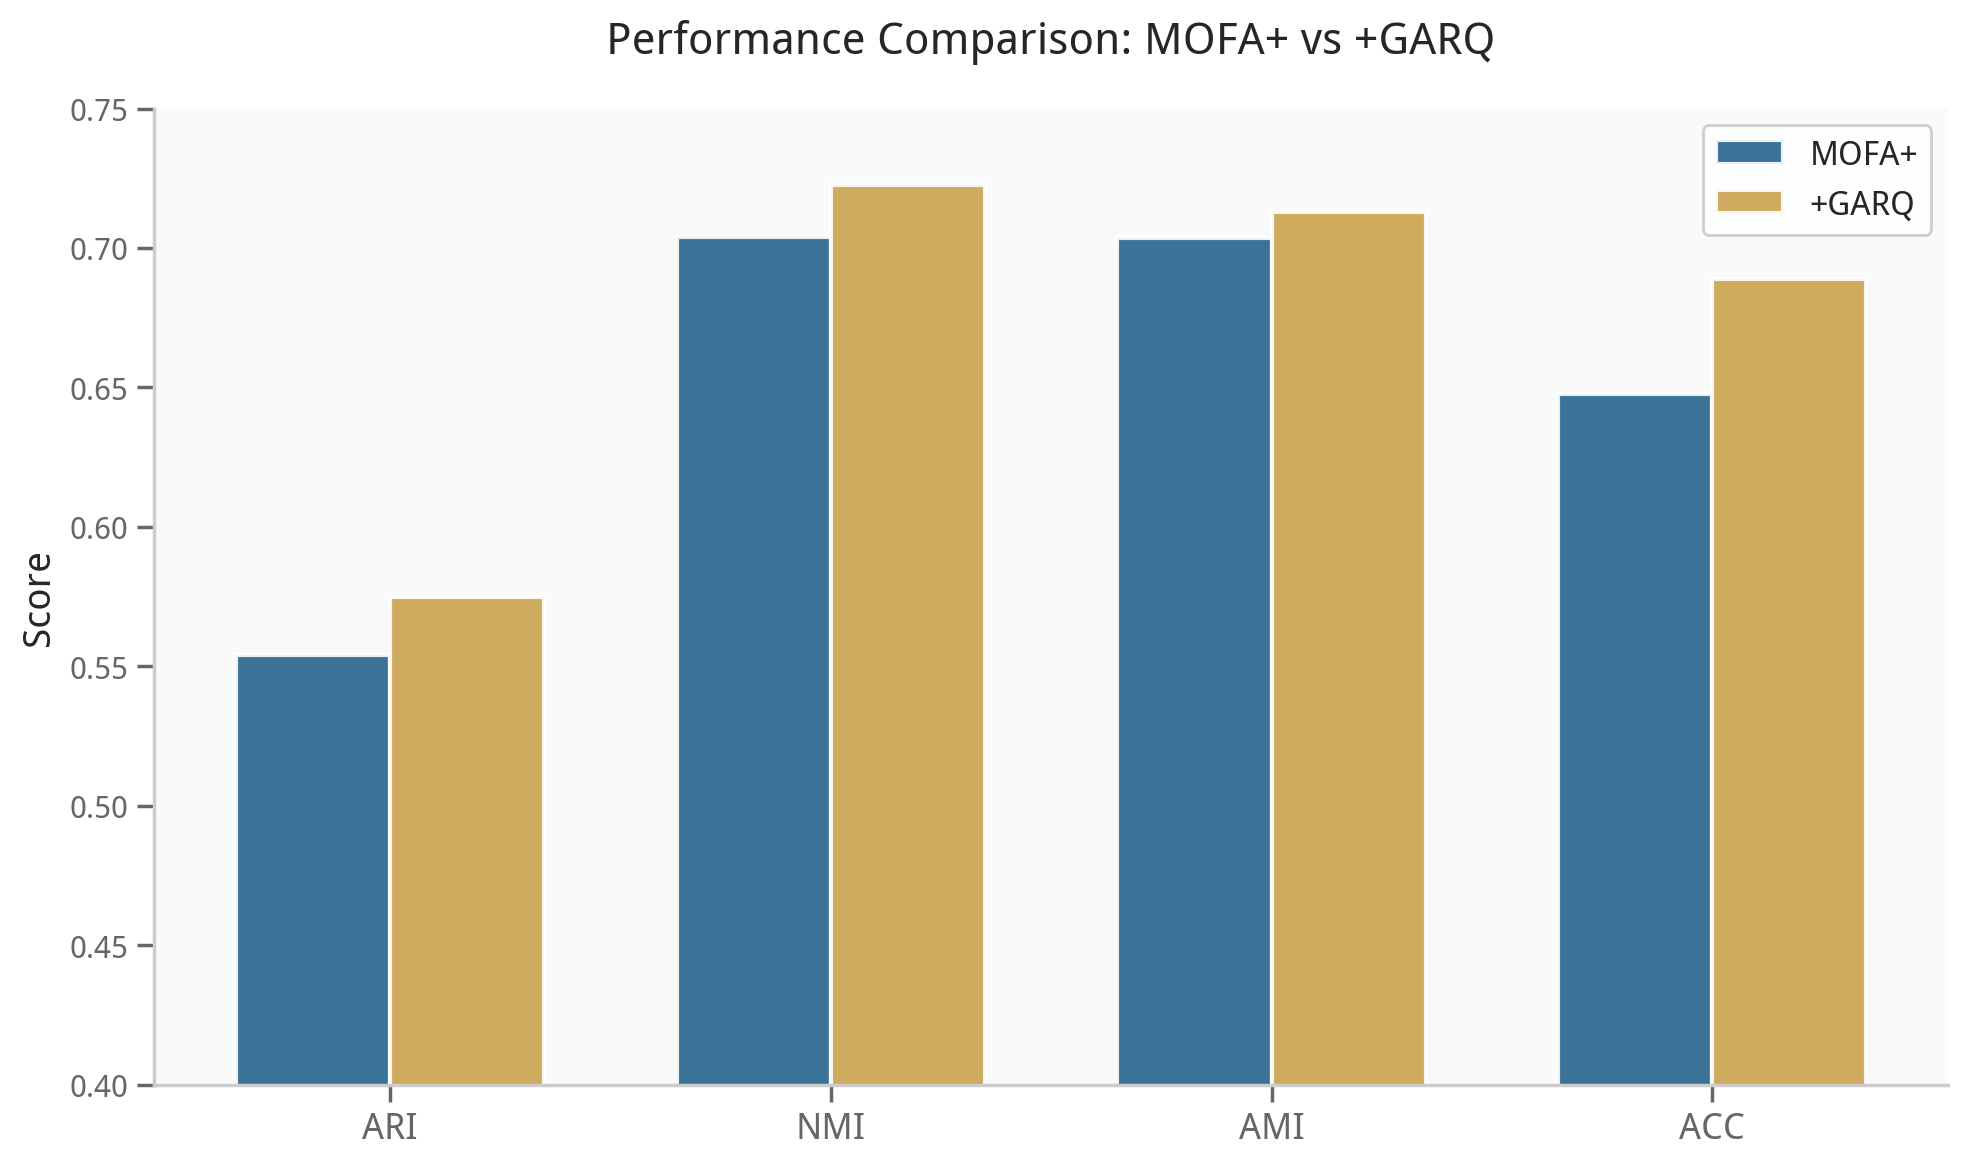

In [8]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['ARI', 'NMI', 'AMI', 'ACC']
values = {
    'MOFA+': [0.5542, 0.7039, 0.7036, 0.6475],
    '+GARQ': [0.5749, 0.7225, 0.7129, 0.6888]
}
# 
# 使用现代配色方案
colors = {
    'MOFA+': '#25638e',    # 蓝色
    '+GARQ': '#c9a24c'     # 金色 43762c  c9a24c
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)

bar_width = 0.35
x = np.arange(len(metrics))

bars_mofa = ax.bar(x - bar_width/2, values['MOFA+'], 
                   bar_width, label='MOFA+', color=colors['MOFA+'], 
                   edgecolor='white', linewidth=1.5, alpha=0.9)

bars_garq = ax.bar(x + bar_width/2, values['+GARQ'], 
                   bar_width, label='+GARQ', color=colors['+GARQ'], 
                   edgecolor='white', linewidth=1.5, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13, fontweight='600')

ax.set_ylabel('Score', fontsize=14, fontweight='600')
ax.set_ylim(0.4, 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.tick_params(colors='#666666', which='both')

ax.set_title('Performance Comparison: MOFA+ vs +GARQ', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=12, frameon=True, 
          shadow=False, fancybox=True, framealpha=0.95)

ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()